In [ ]:
https://drive.google.com/drive/folders/1pJRBEsjZPPWzWDoQMi1O27FUvUiNJ7dp?usp=drive_link

In [ ]:
!pip install ultralytics tensorflow pillow opencv-python matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
model_folder = "/content/drive/MyDrive/yoloresult/result_model"


In [ ]:
# 1) Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) Example path when folder is in My Drive (adjust if different)
# Replace this with the correct path you see in your Drive after adding shortcut
model_folder = "/content/drive/MyDrive/guavamodel"

# 3) List files
import os
for root, dirs, files in os.walk(model_folder):
    print("Folder:", root)
    print(" Subfolders:", dirs)
    print(" Files count:", len(files))
    for f in files:
        print("  -", f)
    print("----------")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder: /content/drive/MyDrive/guavamodel
 Subfolders: []
 Files count: 5
  - best_yolo8.pt
  - best_yolo11.pt
  - best_yolo12.pt
  - best_cnn_model256.h5
  - best_cnn_model640.h5
----------


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Saving images (10).jpg to images (10).jpg


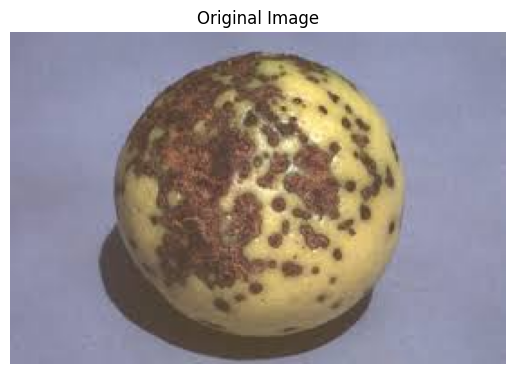


image 1/1 /content/images (10).jpg: 448x640 1 scab, 427.1ms
Speed: 25.6ms preprocess, 427.1ms inference, 40.4ms postprocess per image at shape (1, 3, 448, 640)


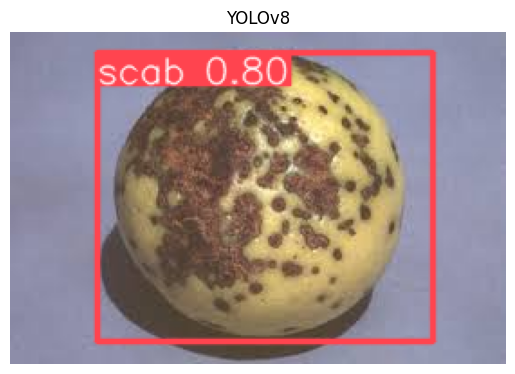


image 1/1 /content/images (10).jpg: 448x640 1 scab, 175.3ms
Speed: 3.3ms preprocess, 175.3ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


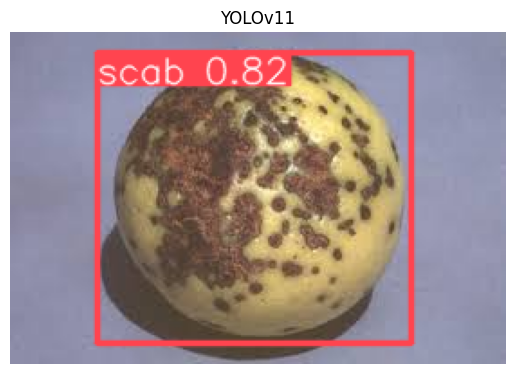


image 1/1 /content/images (10).jpg: 448x640 1 scab, 481.6ms
Speed: 4.7ms preprocess, 481.6ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


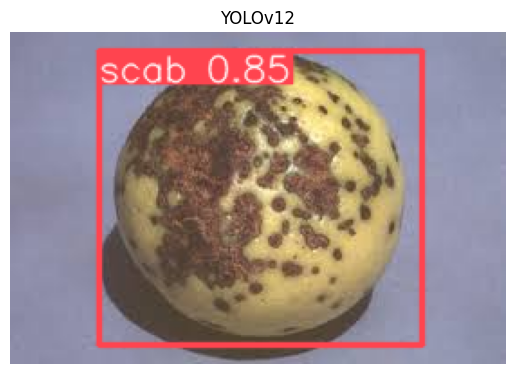

CNN-256: scab (95.61%)
CNN-640: scab (85.10%)

✅ Best YOLO: YOLOv12 (84.59%)
✅ Best CNN: CNN-256 (95.61%)


In [ ]:
# --- Install required libraries ---
!pip install ultralytics tensorflow pillow opencv-python matplotlib --quiet

import os, cv2, numpy as np, matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image
import tensorflow as tf
from google.colab import files

# --- Path to model folder ---
model_folder = "/content/drive/MyDrive/guavamodel"

# --- Load YOLO models ---
yolo_models = {
    "YOLOv8": YOLO(os.path.join(model_folder, "best_yolo8.pt")),
    "YOLOv11": YOLO(os.path.join(model_folder, "best_yolo11.pt")),
    "YOLOv12": YOLO(os.path.join(model_folder, "best_yolo12.pt")),
}

# --- Load CNN models ---
cnn_models = {
    "CNN-256": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model256.h5")),
    "CNN-640": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model640.h5")),
}

cnn_classes = [
    "algal_leaf_spot", "black_mold", "fruit_healthy", "healthy_leaf",
    "insect_bite", "red_rust", "scab", "scorch", "yellow_leaf_disease"
]

# --- Upload a test image ---
uploaded = files.upload()
file_path = list(uploaded.keys())[0]

# --- Load & show original image ---
img_bgr = cv2.imread(file_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

# --- Run YOLO models ---
yolo_scores = {}
for name, model in yolo_models.items():
    results = model(file_path)
    img_result = results[0].plot()
    plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
    plt.title(name)
    plt.axis("off")
    plt.show()

    if results[0].boxes is not None and len(results[0].boxes) > 0:
        confs = [float(b.conf[0].item()) for b in results[0].boxes]
        yolo_scores[name] = np.mean(confs)
    else:
        yolo_scores[name] = 0.0

# --- Run CNN models ---
cnn_scores = {}
for name, cnn in cnn_models.items():
    input_shape = cnn.input_shape[1:3]
    img_resized = cv2.resize(img_rgb, input_shape)
    img_array = np.expand_dims(img_resized.astype(np.float32) / 255.0, axis=0)
    preds = cnn.predict(img_array, verbose=0)
    class_id = int(np.argmax(preds))
    conf = float(np.max(preds))
    class_name = cnn_classes[class_id]
    print(f"{name}: {class_name} ({conf*100:.2f}%)")
    cnn_scores[name] = conf

# --- Best model summary ---
best_yolo = max(yolo_scores, key=yolo_scores.get)
best_cnn = max(cnn_scores, key=cnn_scores.get)

print("\n✅ Best YOLO:", best_yolo, f"({yolo_scores[best_yolo]*100:.2f}%)")
print("✅ Best CNN:", best_cnn, f"({cnn_scores[best_cnn]*100:.2f}%)")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving images (10).jpg to images (10) (1).jpg

image 1/1 /content/images (10) (1).jpg: 448x640 1 scab, 217.8ms
Speed: 5.1ms preprocess, 217.8ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images (10) (1).jpg: 448x640 1 scab, 187.9ms
Speed: 4.0ms preprocess, 187.9ms inference, 3.5ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images (10) (1).jpg: 448x640 1 scab, 467.3ms
Speed: 3.6ms preprocess, 467.3ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


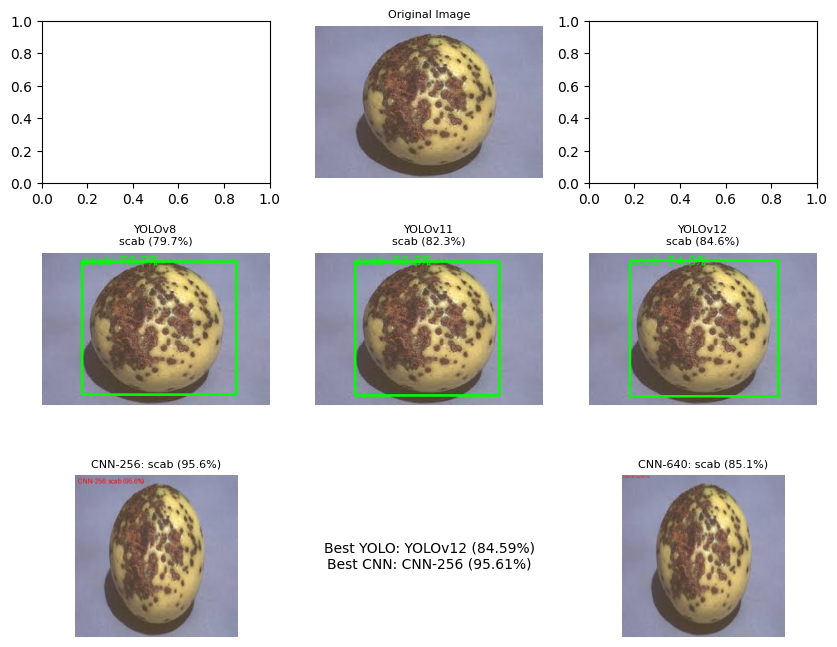

In [ ]:
# ============================
# Install required libraries
# ============================
!pip install ultralytics tensorflow opencv-python pillow matplotlib --quiet

# ============================
# Imports and suppress warnings
# ============================
import os, cv2, numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import tensorflow as tf
from ultralytics import YOLO
from google.colab import files
import logging

# Suppress warnings from TensorFlow/absl
logging.getLogger("absl").setLevel(logging.ERROR)
tf.get_logger().setLevel('ERROR')

# ============================
# Load models from Drive
# ============================
from google.colab import drive
drive.mount('/content/drive')

model_folder = "/content/drive/MyDrive/guavamodel"

yolo_models = {
    "YOLOv8": YOLO(os.path.join(model_folder, "best_yolo8.pt")),
    "YOLOv11": YOLO(os.path.join(model_folder, "best_yolo11.pt")),
    "YOLOv12": YOLO(os.path.join(model_folder, "best_yolo12.pt"))
}

cnn_models = {
    "CNN-256": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model256.h5")),
    "CNN-640": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model640.h5"))
}

cnn_classes = [
    "algal_leaf_spot", "black_mold", "fruit_healthy", "healthy_leaf",
    "insect_bite", "red_rust", "scab", "scorch", "yellow_leaf_disease"
]

# ============================
# Helper functions
# ============================
def overlay_text(img, text):
    """Overlay red text on image (for CNN results)."""
    img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)
    font = ImageFont.load_default()
    draw.text((5,5), text, fill=(255,0,0), font=font)
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

def plot_image(ax, img, title):
    """Plot image on given axis with title."""
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=8)
    ax.axis('off')

# ============================
# Main function
# ============================
def test_all_models(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("❌ Error: Image not found!")
        return

    # Create 3x3 grid
    fig, axes = plt.subplots(3, 3, figsize=(10, 8))
    plt.subplots_adjust(wspace=0.2, hspace=0.4)

    # Original Image
    plot_image(axes[0,1], img_bgr, "Original Image")

    # YOLO models
    yolo_positions = [(1,0), (1,1), (1,2)]
    yolo_scores = {}
    for (name, model), (r, c) in zip(yolo_models.items(), yolo_positions):
        results = model(image_path)
        result = results[0]
        img_copy = img_bgr.copy()
        conf_list = []
        label_list = []

        if result.boxes is not None and len(result.boxes) > 0:
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls_id = int(box.cls[0].item())
                conf = float(box.conf[0].item())
                label = model.names.get(cls_id, f"class_{cls_id}")
                label_list.append(f"{label} ({conf:.1%})")
                conf_list.append(conf)
                cv2.rectangle(img_copy, (x1,y1), (x2,y2), (0,255,0), 2)
                cv2.putText(img_copy, f"{label} {conf:.1%}", (x1, max(15,y1-3)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
        else:
            label_list.append("No detections")
            conf_list.append(0.0)
            cv2.putText(img_copy, "No detections", (5,20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)

        plot_image(axes[r][c], img_copy, f"{name}\n{', '.join(label_list)}")
        yolo_scores[name] = np.mean(conf_list) if conf_list else 0.0

    # CNN models
    cnn_positions = [(2,0), (2,2)]
    cnn_scores = {}
    for (name, cnn), (r, c) in zip(cnn_models.items(), cnn_positions):
        input_shape = cnn.input_shape[1:3]
        img_resized = cv2.resize(img_bgr, input_shape)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        img_array = np.expand_dims(img_rgb.astype(np.float32)/255.0, axis=0)
        preds = cnn.predict(img_array, verbose=0)
        class_id = int(np.argmax(preds))
        conf = float(np.max(preds))
        class_name = cnn_classes[class_id]
        text = f"{name}: {class_name} ({conf*100:.1f}%)"
        img_overlay = overlay_text(img_resized, text)
        plot_image(axes[r][c], img_overlay, text)
        cnn_scores[name] = conf

    # Summary (bottom-center)
    best_yolo = max(yolo_scores, key=yolo_scores.get)
    best_cnn = max(cnn_scores, key=cnn_scores.get)
    summary = (
        f"Best YOLO: {best_yolo} ({yolo_scores[best_yolo]*100:.2f}%)\n"
        f"Best CNN: {best_cnn} ({cnn_scores[best_cnn]*100:.2f}%)"
    )
    axes[2][1].text(0.5, 0.5, summary, ha='center', va='center', fontsize=10)
    axes[2][1].axis('off')

    plt.show()

# ============================
# Upload image and test
# ============================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
test_all_models(image_path)


In [ ]:
right code

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving images (10).jpg to images (10) (2).jpg

image 1/1 /content/images (10) (2).jpg: 448x640 1 scab, 180.9ms
Speed: 3.8ms preprocess, 180.9ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images (10) (2).jpg: 448x640 1 scab, 181.0ms
Speed: 4.1ms preprocess, 181.0ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images (10) (2).jpg: 448x640 1 scab, 444.7ms
Speed: 3.1ms preprocess, 444.7ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


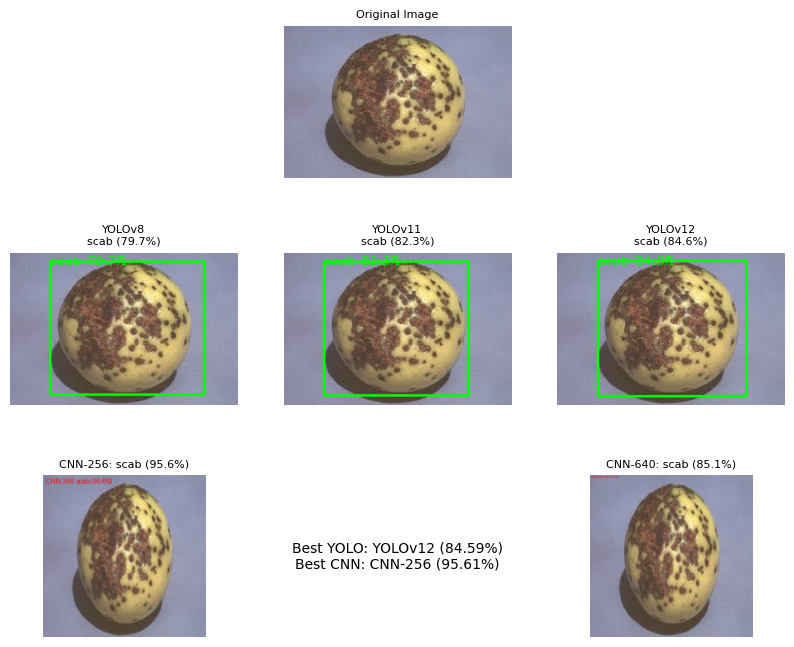

In [ ]:
# ============================
# Install required libraries
# ============================
!pip install ultralytics tensorflow opencv-python pillow matplotlib --quiet

# ============================
# Imports and suppress warnings
# ============================
import os, cv2, numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import tensorflow as tf
from ultralytics import YOLO
from google.colab import files
import logging

# Suppress warnings from TensorFlow/absl
logging.getLogger("absl").setLevel(logging.ERROR)
tf.get_logger().setLevel('ERROR')

# ============================
# Load models from Drive
# ============================
from google.colab import drive
drive.mount('/content/drive')

model_folder = "/content/drive/MyDrive/guavamodel"

yolo_models = {
    "YOLOv8": YOLO(os.path.join(model_folder, "best_yolo8.pt")),
    "YOLOv11": YOLO(os.path.join(model_folder, "best_yolo11.pt")),
    "YOLOv12": YOLO(os.path.join(model_folder, "best_yolo12.pt"))
}

cnn_models = {
    "CNN-256": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model256.h5")),
    "CNN-640": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model640.h5"))
}

cnn_classes = [
    "algal_leaf_spot", "black_mold", "fruit_healthy", "healthy_leaf",
    "insect_bite", "red_rust", "scab", "scorch", "yellow_leaf_disease"
]

# ============================
# Helper functions
# ============================
def overlay_text(img, text):
    """Overlay red text on image (for CNN results)."""
    img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)
    font = ImageFont.load_default()
    draw.text((5,5), text, fill=(255,0,0), font=font)
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

def plot_image(ax, img, title):
    """Plot image on given axis with title."""
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=8)
    ax.axis('off')

def blank_cell(ax):
    """Make the axis completely white."""
    ax.axis('off')
    ax.set_facecolor('white')
    ax.set_xticks([])
    ax.set_yticks([])

# ============================
# Main function
# ============================
def test_all_models(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("❌ Error: Image not found!")
        return

    # Create 3x3 grid
    fig, axes = plt.subplots(3, 3, figsize=(10, 8))
    plt.subplots_adjust(wspace=0.2, hspace=0.4)

    # ----------------------------
    # Top row: Original + blank cells
    # ----------------------------
    blank_cell(axes[0,0])
    plot_image(axes[0,1], img_bgr, "Original Image")
    blank_cell(axes[0,2])

    # ----------------------------
    # YOLO row
    # ----------------------------
    yolo_positions = [(1,0), (1,1), (1,2)]
    yolo_scores = {}
    for (name, model), (r, c) in zip(yolo_models.items(), yolo_positions):
        results = model(image_path)
        result = results[0]
        img_copy = img_bgr.copy()
        conf_list = []
        label_list = []

        if result.boxes is not None and len(result.boxes) > 0:
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls_id = int(box.cls[0].item())
                conf = float(box.conf[0].item())
                label = model.names.get(cls_id, f"class_{cls_id}")
                label_list.append(f"{label} ({conf:.1%})")
                conf_list.append(conf)
                cv2.rectangle(img_copy, (x1,y1), (x2,y2), (0,255,0), 2)
                cv2.putText(img_copy, f"{label} {conf:.1%}", (x1, max(15,y1-3)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
        else:
            label_list.append("No detections")
            conf_list.append(0.0)
            cv2.putText(img_copy, "No detections", (5,20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)

        plot_image(axes[r][c], img_copy, f"{name}\n{', '.join(label_list)}")
        yolo_scores[name] = np.mean(conf_list) if conf_list else 0.0

    # ----------------------------
    # CNN row
    # ----------------------------
    cnn_positions = [(2,0), (2,2)]
    cnn_scores = {}
    for (name, cnn), (r, c) in zip(cnn_models.items(), cnn_positions):
        input_shape = cnn.input_shape[1:3]
        img_resized = cv2.resize(img_bgr, input_shape)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        img_array = np.expand_dims(img_rgb.astype(np.float32)/255.0, axis=0)
        preds = cnn.predict(img_array, verbose=0)
        class_id = int(np.argmax(preds))
        conf = float(np.max(preds))
        class_name = cnn_classes[class_id]
        text = f"{name}: {class_name} ({conf*100:.1f}%)"
        img_overlay = overlay_text(img_resized, text)
        plot_image(axes[r][c], img_overlay, text)
        cnn_scores[name] = conf

    # ----------------------------
    # Summary in center bottom
    # ----------------------------
    best_yolo = max(yolo_scores, key=yolo_scores.get)
    best_cnn = max(cnn_scores, key=cnn_scores.get)
    summary = (
        f"Best YOLO: {best_yolo} ({yolo_scores[best_yolo]*100:.2f}%)\n"
        f"Best CNN: {best_cnn} ({cnn_scores[best_cnn]*100:.2f}%)"
    )
    axes[2][1].text(0.5, 0.5, summary, ha='center', va='center', fontsize=10)
    axes[2][1].set_facecolor('white')
    axes[2][1].axis('off')

    plt.show()

# ============================
# Upload image and test
# ============================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
test_all_models(image_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving images (10).jpg to images (10) (3).jpg

image 1/1 /content/images (10) (3).jpg: 448x640 1 scab, 184.6ms
Speed: 4.3ms preprocess, 184.6ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images (10) (3).jpg: 448x640 1 scab, 158.3ms
Speed: 3.5ms preprocess, 158.3ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images (10) (3).jpg: 448x640 1 scab, 472.6ms
Speed: 3.7ms preprocess, 472.6ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


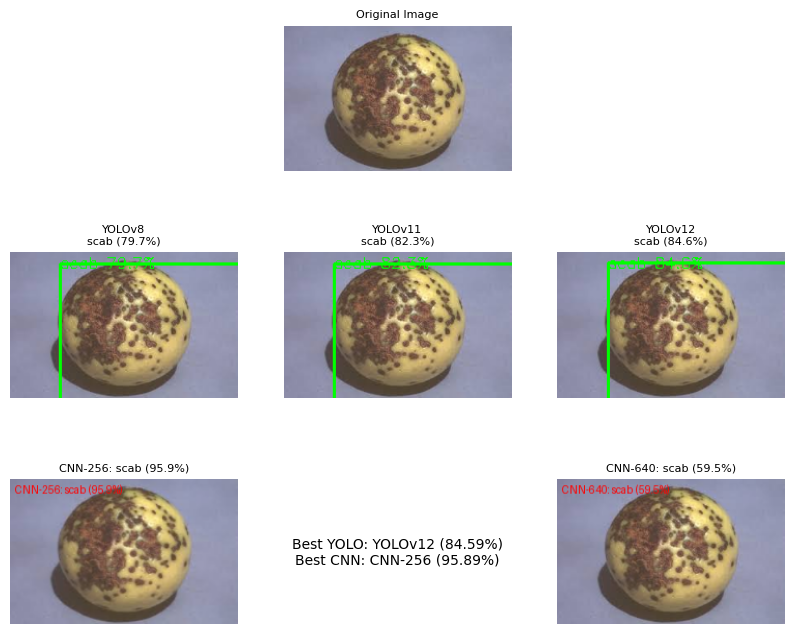

In [ ]:
# ============================
# Install required libraries
# ============================
!pip install ultralytics tensorflow opencv-python pillow matplotlib --quiet

# ============================
# Imports and suppress warnings
# ============================
import os, cv2, numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import tensorflow as tf
from ultralytics import YOLO
from google.colab import files
import logging

# Suppress warnings from TensorFlow/absl
logging.getLogger("absl").setLevel(logging.ERROR)
tf.get_logger().setLevel('ERROR')

# ============================
# Load models from Drive
# ============================
from google.colab import drive
drive.mount('/content/drive')

model_folder = "/content/drive/MyDrive/guavamodel"

yolo_models = {
    "YOLOv8": YOLO(os.path.join(model_folder, "best_yolo8.pt")),
    "YOLOv11": YOLO(os.path.join(model_folder, "best_yolo11.pt")),
    "YOLOv12": YOLO(os.path.join(model_folder, "best_yolo12.pt"))
}

cnn_models = {
    "CNN-256": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model256.h5")),
    "CNN-640": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model640.h5"))
}

cnn_classes = [
    "algal_leaf_spot", "black_mold", "fruit_healthy", "healthy_leaf",
    "insect_bite", "red_rust", "scab", "scorch", "yellow_leaf_disease"
]

# ============================
# Helper functions
# ============================
GRID_SIZE = (220, 140)  # uniform size for all images

def overlay_text(img, text):
    """Overlay red text on image (for CNN results)."""
    img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)
    font = ImageFont.load_default()
    draw.text((5,5), text, fill=(255,0,0), font=font)
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

def resize_img(img, size=GRID_SIZE):
    """Resize image to uniform grid size."""
    return cv2.resize(img, size)

def plot_image(ax, img, title):
    """Plot image on given axis with title."""
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=8)
    ax.axis('off')

def blank_cell(ax):
    """Make the axis completely white."""
    ax.axis('off')
    ax.set_facecolor('white')
    ax.set_xticks([])
    ax.set_yticks([])

# ============================
# Main function
# ============================
def test_all_models(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("❌ Error: Image not found!")
        return

    # Resize original image to grid size
    img_bgr = resize_img(img_bgr)

    # Create 3x3 grid
    fig, axes = plt.subplots(3, 3, figsize=(10, 8))
    plt.subplots_adjust(wspace=0.2, hspace=0.4)

    # ----------------------------
    # Top row: Original + blank cells
    # ----------------------------
    blank_cell(axes[0,0])
    plot_image(axes[0,1], img_bgr, "Original Image")
    blank_cell(axes[0,2])

    # ----------------------------
    # YOLO row
    # ----------------------------
    yolo_positions = [(1,0), (1,1), (1,2)]
    yolo_scores = {}
    for (name, model), (r, c) in zip(yolo_models.items(), yolo_positions):
        results = model(image_path)
        result = results[0]
        img_copy = resize_img(img_bgr.copy())  # uniform size
        conf_list = []
        label_list = []

        if result.boxes is not None and len(result.boxes) > 0:
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls_id = int(box.cls[0].item())
                conf = float(box.conf[0].item())
                label = model.names.get(cls_id, f"class_{cls_id}")
                label_list.append(f"{label} ({conf:.1%})")
                conf_list.append(conf)
                # Rescale boxes to resized image
                x_scale = GRID_SIZE[0] / img_bgr.shape[1]
                y_scale = GRID_SIZE[1] / img_bgr.shape[0]
                x1 = int(x1 * x_scale)
                x2 = int(x2 * x_scale)
                y1 = int(y1 * y_scale)
                y2 = int(y2 * y_scale)
                cv2.rectangle(img_copy, (x1,y1), (x2,y2), (0,255,0), 2)
                cv2.putText(img_copy, f"{label} {conf:.1%}", (x1, max(15,y1-3)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
        else:
            label_list.append("No detections")
            conf_list.append(0.0)
            cv2.putText(img_copy, "No detections", (5,20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)

        plot_image(axes[r][c], img_copy, f"{name}\n{', '.join(label_list)}")
        yolo_scores[name] = np.mean(conf_list) if conf_list else 0.0

    # ----------------------------
    # CNN row
    # ----------------------------
    cnn_positions = [(2,0), (2,2)]
    cnn_scores = {}
    for (name, cnn), (r, c) in zip(cnn_models.items(), cnn_positions):
        input_shape = cnn.input_shape[1:3]
        img_resized = cv2.resize(img_bgr.copy(), input_shape)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        img_array = np.expand_dims(img_rgb.astype(np.float32)/255.0, axis=0)
        preds = cnn.predict(img_array, verbose=0)
        class_id = int(np.argmax(preds))
        conf = float(np.max(preds))
        class_name = cnn_classes[class_id]
        text = f"{name}: {class_name} ({conf*100:.1f}%)"
        img_overlay = overlay_text(resize_img(img_resized), text)
        plot_image(axes[r][c], img_overlay, text)
        cnn_scores[name] = conf

    # ----------------------------
    # Summary in center bottom
    # ----------------------------
    best_yolo = max(yolo_scores, key=yolo_scores.get)
    best_cnn = max(cnn_scores, key=cnn_scores.get)
    summary = (
        f"Best YOLO: {best_yolo} ({yolo_scores[best_yolo]*100:.2f}%)\n"
        f"Best CNN: {best_cnn} ({cnn_scores[best_cnn]*100:.2f}%)"
    )
    axes[2][1].text(0.5, 0.5, summary, ha='center', va='center', fontsize=10)
    axes[2][1].set_facecolor('white')
    axes[2][1].axis('off')

    plt.show()

# ============================
# Upload image and test
# ============================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
test_all_models(image_path)


In [ ]:
Gradio

In [10]:
# ============================
# Install required libraries
# ============================
!pip install ultralytics tensorflow opencv-python pillow matplotlib gradio --quiet

# ============================
# Imports
# ============================
import os, cv2, numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import tensorflow as tf
from ultralytics import YOLO
import gradio as gr
import logging

# Suppress warnings
logging.getLogger("absl").setLevel(logging.ERROR)
tf.get_logger().setLevel('ERROR')

# ============================
# Load models from Drive
# ============================
from google.colab import drive
drive.mount('/content/drive')

model_folder = "/content/drive/MyDrive/guavamodel"

yolo_models = {
    "YOLOv8": YOLO(os.path.join(model_folder, "best_yolo8.pt")),
    "YOLOv11": YOLO(os.path.join(model_folder, "best_yolo11.pt")),
    "YOLOv12": YOLO(os.path.join(model_folder, "best_yolo12.pt"))
}

cnn_models = {
    "CNN-256": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model256.h5")),
    "CNN-640": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model640.h5"))
}

cnn_classes = [
    "algal_leaf_spot", "black_mold", "fruit_healthy", "healthy_leaf",
    "insect_bite", "red_rust", "scab", "scorch", "yellow_leaf_disease"
]

# ============================
# Helper functions
# ============================
GRID_SIZE = (220, 140)

def overlay_text(img, text):
    img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)
    font = ImageFont.load_default()
    draw.text((5,5), text, fill=(255,0,0), font=font)
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

def resize_img(img, size=GRID_SIZE):
    return cv2.resize(img, size)

def blank_cell(ax):
    ax.axis('off')
    ax.set_facecolor('white')
    ax.set_xticks([])
    ax.set_yticks([])

def create_grid(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None

    img_bgr = resize_img(img_bgr)
    fig, axes = plt.subplots(3,3, figsize=(10,8))
    plt.subplots_adjust(wspace=0.2, hspace=0.4)

    # Top row
    blank_cell(axes[0,0])
    axes[0,1].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0,1].set_title("Original", fontsize=8)
    blank_cell(axes[0,2])

    # YOLO row
    yolo_positions = [(1,0),(1,1),(1,2)]
    yolo_scores = {}
    for (name, model),(r,c) in zip(yolo_models.items(), yolo_positions):
        results = model(image_path)
        result = results[0]
        img_copy = resize_img(img_bgr.copy())
        conf_list = []
        label_list = []
        if result.boxes is not None and len(result.boxes)>0:
            for box in result.boxes:
                x1,y1,x2,y2 = map(int,box.xyxy[0])
                cls_id = int(box.cls[0].item())
                conf = float(box.conf[0].item())
                label = model.names.get(cls_id,f"class_{cls_id}")
                label_list.append(f"{label} ({conf:.1%})")
                conf_list.append(conf)
                x_scale = GRID_SIZE[0]/img_bgr.shape[1]
                y_scale = GRID_SIZE[1]/img_bgr.shape[0]
                x1 = int(x1*x_scale)
                x2 = int(x2*x_scale)
                y1 = int(y1*y_scale)
                y2 = int(y2*y_scale)
                cv2.rectangle(img_copy,(x1,y1),(x2,y2),(0,255,0),2)
                cv2.putText(img_copy,f"{label} {conf:.1%}",(x1,max(15,y1-3)),
                            cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),1)
        else:
            label_list.append("No detections")
            conf_list.append(0.0)
            cv2.putText(img_copy,"No detections",(5,20),
                        cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,0,255),1)
        axes[r,c].imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
        axes[r,c].set_title(f"{name}\n{', '.join(label_list)}", fontsize=8)
        axes[r,c].axis('off')
        yolo_scores[name] = np.mean(conf_list) if conf_list else 0.0

    # CNN row
    cnn_positions = [(2,0),(2,2)]
    cnn_scores = {}
    for (name, cnn),(r,c) in zip(cnn_models.items(),cnn_positions):
        input_shape = cnn.input_shape[1:3]
        img_resized = cv2.resize(img_bgr.copy(),input_shape)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        img_array = np.expand_dims(img_rgb.astype(np.float32)/255.0, axis=0)
        preds = cnn.predict(img_array,verbose=0)
        class_id = int(np.argmax(preds))
        conf = float(np.max(preds))
        class_name = cnn_classes[class_id]
        text = f"{name}: {class_name} ({conf*100:.1f}%)"
        img_overlay = overlay_text(resize_img(img_resized), text)
        axes[r,c].imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
        axes[r,c].set_title(text, fontsize=8)
        axes[r,c].axis('off')
        cnn_scores[name] = conf

    # Summary
    best_yolo = max(yolo_scores, key=yolo_scores.get)
    best_cnn = max(cnn_scores, key=cnn_scores.get)
    summary = f"Best YOLO: {best_yolo} ({yolo_scores[best_yolo]*100:.2f}%)\nBest CNN: {best_cnn} ({cnn_scores[best_cnn]*100:.2f}%)"
    axes[2,1].text(0.5,0.5,summary,ha='center',va='center',fontsize=10)
    axes[2,1].set_facecolor('white')
    axes[2,1].axis('off')

    # Save figure to return
    output_path = "result_grid.png"
    plt.savefig(output_path, bbox_inches='tight')
    plt.close(fig)
    return output_path

# ============================
# Launch Gradio Interface
# ============================
iface = gr.Interface(
    fn=create_grid,
    inputs=gr.Image(type="filepath", label="Upload Guava Leaf Image"),
    outputs=gr.Image(type="filepath", label="Result Grid"),
    title="🌿 Guava Disease Detection - Multi-Model 🌿",
    description="Upload a guava leaf image and see YOLO and CNN predictions in a 3x3 grid."
)

iface.launch()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2f5960efc2f82a0635.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
# ============================
# Install required libraries
# ============================
!pip install ultralytics tensorflow opencv-python pillow matplotlib gradio --quiet

# ============================
# Imports
# ============================
import os, cv2, numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import tensorflow as tf
from ultralytics import YOLO
import gradio as gr
import logging

# Suppress warnings
logging.getLogger("absl").setLevel(logging.ERROR)
tf.get_logger().setLevel('ERROR')

# ============================
# Mount Google Drive
# ============================
from google.colab import drive
drive.mount('/content/drive')

# ============================
# Load models
# ============================
model_folder = "/content/drive/MyDrive/guavamodel"

yolo_models = {
    "YOLOv8": YOLO(os.path.join(model_folder, "best_yolo8.pt")),
    "YOLOv11": YOLO(os.path.join(model_folder, "best_yolo11.pt")),
    "YOLOv12": YOLO(os.path.join(model_folder, "best_yolo12.pt"))
}

cnn_models = {
    "CNN-256": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model256.h5")),
    "CNN-640": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model640.h5"))
}

cnn_classes = [
    "algal_leaf_spot", "black_mold", "fruit_healthy", "healthy_leaf",
    "insect_bite", "red_rust", "scab", "scorch", "yellow_leaf_disease"
]

# ============================
# Helper functions
# ============================
GRID_SIZE = (220, 140)

def overlay_text(img, text):
    img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)
    font = ImageFont.load_default()
    draw.text((5,5), text, fill=(255,0,0), font=font)
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

def resize_img(img, size=GRID_SIZE):
    return cv2.resize(img, size)

def blank_cell(ax):
    ax.axis('off')
    ax.set_facecolor('white')
    ax.set_xticks([])
    ax.set_yticks([])

def create_grid(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None

    img_bgr = resize_img(img_bgr)
    fig, axes = plt.subplots(3,3, figsize=(10,8))
    plt.subplots_adjust(wspace=0.2, hspace=0.4)

    # ----------------------------
    # Top row: blank + original + blank
    # ----------------------------
    blank_cell(axes[0,0])
    axes[0,1].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0,1].set_title("Original Image", fontsize=8)
    blank_cell(axes[0,2])

    # ----------------------------
    # YOLO row
    # ----------------------------
    yolo_positions = [(1,0),(1,1),(1,2)]
    yolo_scores = {}
    for (name, model),(r,c) in zip(yolo_models.items(), yolo_positions):
        results = model(image_path)
        result = results[0]
        img_copy = resize_img(img_bgr.copy())
        conf_list = []
        label_list = []
        if result.boxes is not None and len(result.boxes)>0:
            for box in result.boxes:
                x1,y1,x2,y2 = map(int, box.xyxy[0])
                cls_id = int(box.cls[0].item())
                conf = float(box.conf[0].item())
                label = model.names.get(cls_id, f"class_{cls_id}")
                label_list.append(f"{label} ({conf:.1%})")
                conf_list.append(conf)
                x_scale = GRID_SIZE[0] / img_bgr.shape[1]
                y_scale = GRID_SIZE[1] / img_bgr.shape[0]
                x1 = int(x1*x_scale)
                x2 = int(x2*x_scale)
                y1 = int(y1*y_scale)
                y2 = int(y2*y_scale)
                cv2.rectangle(img_copy,(x1,y1),(x2,y2),(0,255,0),2)
                cv2.putText(img_copy,f"{label} {conf:.1%}",(x1,max(15,y1-3)),
                            cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),1)
        else:
            label_list.append("No detections")
            conf_list.append(0.0)
            cv2.putText(img_copy,"No detections",(5,20),
                        cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,0,255),1)
        axes[r,c].imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
        axes[r,c].set_title(f"{name}\n{', '.join(label_list)}", fontsize=8)
        axes[r,c].axis('off')
        yolo_scores[name] = np.mean(conf_list) if conf_list else 0.0

    # ----------------------------
    # CNN row
    # ----------------------------
    cnn_positions = [(2,0),(2,2)]
    cnn_scores = {}
    for (name, cnn),(r,c) in zip(cnn_models.items(),cnn_positions):
        input_shape = cnn.input_shape[1:3]
        img_resized = cv2.resize(img_bgr.copy(), input_shape)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        img_array = np.expand_dims(img_rgb.astype(np.float32)/255.0, axis=0)
        preds = cnn.predict(img_array,verbose=0)
        class_id = int(np.argmax(preds))
        conf = float(np.max(preds))
        class_name = cnn_classes[class_id]
        text = f"{name}: {class_name} ({conf*100:.1f}%)"
        img_overlay = overlay_text(resize_img(img_resized), text)
        axes[r,c].imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
        axes[r,c].set_title(text, fontsize=8)
        axes[r,c].axis('off')
        cnn_scores[name] = conf

    # ----------------------------
    # Summary in center bottom
    # ----------------------------
    best_yolo = max(yolo_scores, key=yolo_scores.get)
    best_cnn = max(cnn_scores, key=cnn_scores.get)
    summary = f"Best YOLO: {best_yolo} ({yolo_scores[best_yolo]*100:.2f}%)\nBest CNN: {best_cnn} ({cnn_scores[best_cnn]*100:.2f}%)"
    axes[2,1].text(0.5,0.5,summary,ha='center',va='center',fontsize=10)
    axes[2,1].set_facecolor('white')
    axes[2,1].axis('off')

    # Save figure to a temporary path
    output_path = "result_grid.png"
    plt.savefig(output_path, bbox_inches='tight')
    plt.close(fig)
    return output_path

# ============================
# Gradio interface
# ============================
iface = gr.Interface(
    fn=create_grid,
    inputs=gr.Image(type="filepath", label="Upload Guava Leaf Image"),
    outputs=gr.Image(type="filepath", label="Result Grid"),
    title="🌿 Guava Disease Detection - Multi-Model 🌿",
    description="Upload a guava leaf image and see YOLO and CNN predictions in a 3x3 grid."
)

# Launch in Colab with inline display
iface.launch(share=True, debug=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a51017106f6048446a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1134, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",


image 1/1 /tmp/gradio/ef4510503d7228dd7f0c99c9cc1b89af227f2486b70d17f47f8dc01486ad8a24/images 10.jpg: 448x640 1 scab, 168.6ms
Speed: 5.7ms preprocess, 168.6ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /tmp/gradio/ef4510503d7228dd7f0c99c9cc1b89af227f2486b70d17f47f8dc01486ad8a24/images 10.jpg: 448x640 1 scab, 171.3ms
Speed: 3.5ms preprocess, 171.3ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /tmp/gradio/ef4510503d7228dd7f0c99c9cc1b89af227f2486b70d17f47f8dc01486ad8a24/images 10.jpg: 448x640 1 scab, 457.2ms
Speed: 4.4ms preprocess, 457.2ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1134, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",


image 1/1 /tmp/gradio/ef4510503d7228dd7f0c99c9cc1b89af227f2486b70d17f47f8dc01486ad8a24/images 10.jpg: 448x640 1 scab, 177.8ms
Speed: 3.2ms preprocess, 177.8ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /tmp/gradio/ef4510503d7228dd7f0c99c9cc1b89af227f2486b70d17f47f8dc01486ad8a24/images 10.jpg: 448x640 1 scab, 161.0ms
Speed: 3.7ms preprocess, 161.0ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /tmp/gradio/ef4510503d7228dd7f0c99c9cc1b89af227f2486b70d17f47f8dc01486ad8a24/images 10.jpg: 448x640 1 scab, 448.6ms
Speed: 3.2ms preprocess, 448.6ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://2f5960efc2f82a0635.gradio.live
Killing tunnel 127.0.0.1:7861 <> https://a51017106f6048446a.gradio.live


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving images (10).jpg to images (10) (4).jpg

image 1/1 /content/images (10) (4).jpg: 448x640 1 scab, 190.3ms
Speed: 3.3ms preprocess, 190.3ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images (10) (4).jpg: 448x640 1 scab, 159.1ms
Speed: 3.2ms preprocess, 159.1ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images (10) (4).jpg: 448x640 1 scab, 435.4ms
Speed: 3.1ms preprocess, 435.4ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


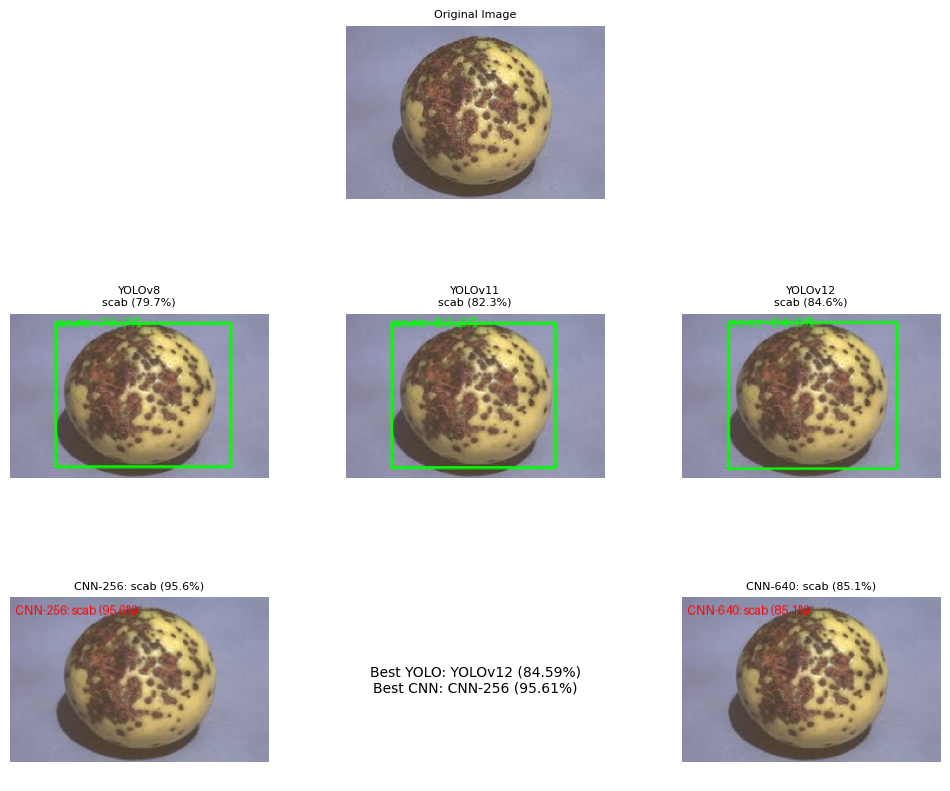

In [12]:
# ============================
# Install required libraries
# ============================
!pip install ultralytics tensorflow opencv-python pillow matplotlib --quiet

# ============================
# Imports
# ============================
import os, cv2, numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import tensorflow as tf
from ultralytics import YOLO
from google.colab import files, drive
import logging

# Suppress warnings
logging.getLogger("absl").setLevel(logging.ERROR)
tf.get_logger().setLevel('ERROR')

# ============================
# Mount Google Drive
# ============================
drive.mount('/content/drive')

# ============================
# Load models
# ============================
model_folder = "/content/drive/MyDrive/guavamodel"

yolo_models = {
    "YOLOv8": YOLO(os.path.join(model_folder, "best_yolo8.pt")),
    "YOLOv11": YOLO(os.path.join(model_folder, "best_yolo11.pt")),
    "YOLOv12": YOLO(os.path.join(model_folder, "best_yolo12.pt"))
}

cnn_models = {
    "CNN-256": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model256.h5")),
    "CNN-640": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model640.h5"))
}

cnn_classes = [
    "algal_leaf_spot", "black_mold", "fruit_healthy", "healthy_leaf",
    "insect_bite", "red_rust", "scab", "scorch", "yellow_leaf_disease"
]

# ============================
# Helper functions
# ============================
def overlay_text(img, text):
    img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)
    font = ImageFont.load_default()
    draw.text((5,5), text, fill=(255,0,0), font=font)
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

def plot_image(ax, img, title):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=8)
    ax.axis('off')

def blank_cell(ax):
    ax.axis('off')
    ax.set_facecolor('white')
    ax.set_xticks([])
    ax.set_yticks([])

# ============================
# Main function
# ============================
def test_all_models(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("❌ Error: Image not found!")
        return

    original_img = img_bgr.copy()  # keep original size for YOLO

    # Create 3x3 grid
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    plt.subplots_adjust(wspace=0.3, hspace=0.4)

    # ----------------------------
    # Top row: blank + original + blank
    # ----------------------------
    blank_cell(axes[0,0])
    plot_image(axes[0,1], original_img, "Original Image")
    blank_cell(axes[0,2])

    # ----------------------------
    # YOLO row
    # ----------------------------
    yolo_positions = [(1,0), (1,1), (1,2)]
    yolo_scores = {}
    for (name, model), (r, c) in zip(yolo_models.items(), yolo_positions):
        results = model(image_path)
        result = results[0]
        img_copy = original_img.copy()
        conf_list = []
        label_list = []

        if result.boxes is not None and len(result.boxes) > 0:
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls_id = int(box.cls[0].item())
                conf = float(box.conf[0].item())
                label = model.names.get(cls_id, f"class_{cls_id}")
                label_list.append(f"{label} ({conf:.1%})")
                conf_list.append(conf)
                # Draw box
                cv2.rectangle(img_copy, (x1,y1), (x2,y2), (0,255,0), 2)
                cv2.putText(img_copy, f"{label} {conf:.1%}", (x1, max(15,y1-3)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
        else:
            label_list.append("No detections")
            conf_list.append(0.0)
            cv2.putText(img_copy, "No detections", (5,20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)

        # Resize for grid display but keep YOLO boxes correct
        img_grid = cv2.resize(img_copy, (220, 140))
        plot_image(axes[r][c], img_grid, f"{name}\n{', '.join(label_list)}")
        yolo_scores[name] = np.mean(conf_list) if conf_list else 0.0

    # ----------------------------
    # CNN row
    # ----------------------------
    cnn_positions = [(2,0), (2,2)]
    cnn_scores = {}
    for (name, cnn), (r, c) in zip(cnn_models.items(), cnn_positions):
        input_shape = cnn.input_shape[1:3]
        img_resized = cv2.resize(original_img.copy(), input_shape)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        img_array = np.expand_dims(img_rgb.astype(np.float32)/255.0, axis=0)
        preds = cnn.predict(img_array, verbose=0)
        class_id = int(np.argmax(preds))
        conf = float(np.max(preds))
        class_name = cnn_classes[class_id]
        text = f"{name}: {class_name} ({conf*100:.1f}%)"
        img_overlay = overlay_text(cv2.resize(img_resized, (220,140)), text)
        plot_image(axes[r][c], img_overlay, text)
        cnn_scores[name] = conf

    # ----------------------------
    # Summary in center bottom
    # ----------------------------
    best_yolo = max(yolo_scores, key=yolo_scores.get)
    best_cnn = max(cnn_scores, key=cnn_scores.get)
    summary = f"Best YOLO: {best_yolo} ({yolo_scores[best_yolo]*100:.2f}%)\nBest CNN: {best_cnn} ({cnn_scores[best_cnn]*100:.2f}%)"
    axes[2,1].text(0.5,0.5,summary, ha='center', va='center', fontsize=10)
    axes[2,1].set_facecolor('white')
    axes[2,1].axis('off')

    plt.show()

# ============================
# Upload image and test
# ============================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
test_all_models(image_path)


In [13]:
# ============================
# Install required libraries
# ============================
!pip install ultralytics tensorflow opencv-python pillow matplotlib gradio --quiet

# ============================
# Imports
# ============================
import os, cv2, numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import tensorflow as tf
from ultralytics import YOLO
import gradio as gr
import logging

# Suppress warnings
logging.getLogger("absl").setLevel(logging.ERROR)
tf.get_logger().setLevel('ERROR')

# ============================
# Mount Google Drive
# ============================
from google.colab import drive
drive.mount('/content/drive')

# ============================
# Load models
# ============================
model_folder = "/content/drive/MyDrive/guavamodel"

yolo_models = {
    "YOLOv8": YOLO(os.path.join(model_folder, "best_yolo8.pt")),
    "YOLOv11": YOLO(os.path.join(model_folder, "best_yolo11.pt")),
    "YOLOv12": YOLO(os.path.join(model_folder, "best_yolo12.pt"))
}

cnn_models = {
    "CNN-256": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model256.h5")),
    "CNN-640": tf.keras.models.load_model(os.path.join(model_folder, "best_cnn_model640.h5"))
}

cnn_classes = [
    "algal_leaf_spot", "black_mold", "fruit_healthy", "healthy_leaf",
    "insect_bite", "red_rust", "scab", "scorch", "yellow_leaf_disease"
]

# ============================
# Helper functions
# ============================
GRID_SIZE = (220, 140)

def overlay_text(img, text):
    img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)
    font = ImageFont.load_default()
    draw.text((5,5), text, fill=(255,0,0), font=font)
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

def resize_img(img, size=GRID_SIZE):
    return cv2.resize(img, size)

def blank_cell(ax):
    ax.axis('off')
    ax.set_facecolor('white')
    ax.set_xticks([])
    ax.set_yticks([])

def create_grid(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None

    original_img = img_bgr.copy()  # Keep original for YOLO boxes

    fig, axes = plt.subplots(3,3, figsize=(10,8))
    plt.subplots_adjust(wspace=0.2, hspace=0.4)

    # ----------------------------
    # Top row: blank + original + blank
    # ----------------------------
    blank_cell(axes[0,0])
    axes[0,1].imshow(cv2.cvtColor(resize_img(original_img), cv2.COLOR_BGR2RGB))
    axes[0,1].set_title("Original Image", fontsize=8)
    blank_cell(axes[0,2])

    # ----------------------------
    # YOLO row
    # ----------------------------
    yolo_positions = [(1,0),(1,1),(1,2)]
    yolo_scores = {}
    for (name, model),(r,c) in zip(yolo_models.items(), yolo_positions):
        results = model(image_path)
        result = results[0]
        img_copy = original_img.copy()  # Draw boxes on full size
        conf_list = []
        label_list = []

        if result.boxes is not None and len(result.boxes)>0:
            for box in result.boxes:
                x1,y1,x2,y2 = map(int, box.xyxy[0])
                cls_id = int(box.cls[0].item())
                conf = float(box.conf[0].item())
                label = model.names.get(cls_id, f"class_{cls_id}")
                label_list.append(f"{label} ({conf:.1%})")
                conf_list.append(conf)
                cv2.rectangle(img_copy,(x1,y1),(x2,y2),(0,255,0),2)
                cv2.putText(img_copy,f"{label} {conf:.1%}",(x1,max(15,y1-3)),
                            cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),1)
        else:
            label_list.append("No detections")
            conf_list.append(0.0)
            cv2.putText(img_copy,"No detections",(5,20),
                        cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,0,255),1)

        # Resize after drawing YOLO boxes
        img_grid = resize_img(img_copy)
        axes[r,c].imshow(cv2.cvtColor(img_grid, cv2.COLOR_BGR2RGB))
        axes[r,c].set_title(f"{name}\n{', '.join(label_list)}", fontsize=8)
        axes[r,c].axis('off')
        yolo_scores[name] = np.mean(conf_list) if conf_list else 0.0

    # ----------------------------
    # CNN row
    # ----------------------------
    cnn_positions = [(2,0),(2,2)]
    cnn_scores = {}
    for (name, cnn),(r,c) in zip(cnn_models.items(),cnn_positions):
        input_shape = cnn.input_shape[1:3]
        img_resized = cv2.resize(original_img.copy(), input_shape)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        img_array = np.expand_dims(img_rgb.astype(np.float32)/255.0, axis=0)
        preds = cnn.predict(img_array,verbose=0)
        class_id = int(np.argmax(preds))
        conf = float(np.max(preds))
        class_name = cnn_classes[class_id]
        text = f"{name}: {class_name} ({conf*100:.1f}%)"
        img_overlay = overlay_text(resize_img(img_resized), text)
        axes[r,c].imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
        axes[r,c].set_title(text, fontsize=8)
        axes[r,c].axis('off')
        cnn_scores[name] = conf

    # ----------------------------
    # Summary in center bottom
    # ----------------------------
    best_yolo = max(yolo_scores, key=yolo_scores.get)
    best_cnn = max(cnn_scores, key=cnn_scores.get)
    summary = f"Best YOLO: {best_yolo} ({yolo_scores[best_yolo]*100:.2f}%)\nBest CNN: {best_cnn} ({cnn_scores[best_cnn]*100:.2f}%)"
    axes[2,1].text(0.5,0.5,summary,ha='center',va='center',fontsize=10)
    axes[2,1].set_facecolor('white')
    axes[2,1].axis('off')

    # Save figure to a temporary path
    output_path = "result_grid.png"
    plt.savefig(output_path, bbox_inches='tight')
    plt.close(fig)
    return output_path

# ============================
# Gradio interface
# ============================
iface = gr.Interface(
    fn=create_grid,
    inputs=gr.Image(type="filepath", label="Upload Guava Leaf Image"),
    outputs=gr.Image(type="filepath", label="Result Grid"),
    title="🌿 Guava Disease Detection - Multi-Model 🌿",
    description="Upload a guava leaf image and see YOLO and CNN predictions in a 3x3 grid with full YOLO boxes."
)

# Launch in Colab
iface.launch(share=True, debug=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://526d257080929485d8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1134, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",


image 1/1 /tmp/gradio/ef4510503d7228dd7f0c99c9cc1b89af227f2486b70d17f47f8dc01486ad8a24/images 10.jpg: 448x640 1 scab, 170.4ms
Speed: 5.4ms preprocess, 170.4ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /tmp/gradio/ef4510503d7228dd7f0c99c9cc1b89af227f2486b70d17f47f8dc01486ad8a24/images 10.jpg: 448x640 1 scab, 170.9ms
Speed: 3.7ms preprocess, 170.9ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /tmp/gradio/ef4510503d7228dd7f0c99c9cc1b89af227f2486b70d17f47f8dc01486ad8a24/images 10.jpg: 448x640 1 scab, 434.7ms
Speed: 4.7ms preprocess, 434.7ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1134, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",


image 1/1 /tmp/gradio/988d65458ebfd71923d995e159500d05dde22dac34327376716233c99375aa8c/17617484639799106938744750208665.jpg: 640x480 (no detections), 189.8ms
Speed: 4.3ms preprocess, 189.8ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /tmp/gradio/988d65458ebfd71923d995e159500d05dde22dac34327376716233c99375aa8c/17617484639799106938744750208665.jpg: 640x480 (no detections), 189.5ms
Speed: 4.3ms preprocess, 189.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /tmp/gradio/988d65458ebfd71923d995e159500d05dde22dac34327376716233c99375aa8c/17617484639799106938744750208665.jpg: 640x480 (no detections), 528.1ms
Speed: 4.3ms preprocess, 528.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)


...


image 1/1 /tmp/gradio/da73b73bff77e2b218cbebcfa75047331f7c3a44cd7dcc5d027c9b0a20abb351/images 5.jpg: 640x640 (no detections), 287.5ms
Speed: 8.0ms preprocess, 287.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /tmp/gradio/da73b73bff77e2b218cbebcfa75047331f7c3a44cd7dcc5d027c9b0a20abb351/images 5.jpg: 640x640 1 healthy_leaf, 253.5ms
Speed: 8.4ms preprocess, 253.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /tmp/gradio/da73b73bff77e2b218cbebcfa75047331f7c3a44cd7dcc5d027c9b0a20abb351/images 5.jpg: 640x640 (no detections), 778.4ms
Speed: 7.1ms preprocess, 778.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1134, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",


image 1/1 /tmp/gradio/12a9bfc915950d04051171fc75b19c2e13fffac45f5d24968ea7ef4864bbcd63/black_mold04.jpg: 640x640 1 black_mold, 285.3ms
Speed: 7.0ms preprocess, 285.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /tmp/gradio/12a9bfc915950d04051171fc75b19c2e13fffac45f5d24968ea7ef4864bbcd63/black_mold04.jpg: 640x640 1 black_mold, 212.4ms
Speed: 5.0ms preprocess, 212.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /tmp/gradio/12a9bfc915950d04051171fc75b19c2e13fffac45f5d24968ea7ef4864bbcd63/black_mold04.jpg: 640x640 1 black_mold, 666.0ms
Speed: 4.7ms preprocess, 666.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1134, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",


image 1/1 /tmp/gradio/6fd4d290c6f9e6c8171bfdb6b82959ffd21a17254fe5ffe7736d90e8780faa5f/sddefault.jpg: 480x640 1 fruit_healthy, 181.5ms
Speed: 3.4ms preprocess, 181.5ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /tmp/gradio/6fd4d290c6f9e6c8171bfdb6b82959ffd21a17254fe5ffe7736d90e8780faa5f/sddefault.jpg: 480x640 1 fruit_healthy, 167.8ms
Speed: 2.5ms preprocess, 167.8ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /tmp/gradio/6fd4d290c6f9e6c8171bfdb6b82959ffd21a17254fe5ffe7736d90e8780faa5f/sddefault.jpg: 480x640 1 fruit_healthy, 509.6ms
Speed: 2.2ms preprocess, 509.6ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7861 <> https://526d257080929485d8.gradio.live
